# Project Title

## Understanding Employee Turnover Through HR Data Analytics

---

## Introduction 
__Introduction to the topic__ 

Over the last 5 years (2018-2023),over __50%__ of the employees have left the company for several reasons. In 2023, exits exceeded new hires for the first time, which might lead to underperforming overall, leading to __shutdown__ the company eventually. A study has been made to __analyze who is leaving__ and understand the __reasons__ behind it if possible using employees data, engagment surveys, and training data. Such study can improve the current and future HR decisions before terminating anyone, lunching a training program, or even hiring someone in the first place.

    ...

---

## Problem Statement

__Hr Department__ has reported __50%__ of employees leaving, over the past __6 years__, leading to company __shinkage__.

    ...

## Objectives:
__Questions that will guide the analysis to solve the problem__

1. What are the numbers of hires vs exits over the past 6 years, and how does it varies yearly?
2. How much do each termination type represents compared to the number of total employees?
3. What department has reported the highest amount of employees leaving it?
4. what jobs has the highest leaving rates?
5. What department has the highest dissatisfaction rating and does leaving rate correlates with it?
6. What devisions have the top leaving percentage? 
7. How much do the employees tend to stay before they decide to leave?
8. How does the Exits changes in every department each year?

    ...

---

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [226]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt   
import pandas as pd  
import seaborn as sns


In [27]:
def read_csv_date(path,date_cols):
    """
        This function loads the file to read it and converts the dates colomns to dates
        """
    return pd.read_csv(path, parse_dates=date_cols, date_format='mixed')
# files dics to read and convert date colomns
file_config = {'emp_df':('employee_data.csv',['StartDate','ExitDate','DOB']),
               'emp_eng_df':('employee_engagement_survey_data.csv',['Survey Date']),
               'emp_trn_df':('training_and_development_data.csv',['Training Date']),}


dfs = {name: read_csv_date(path,date_cols) for name, (path,date_cols) in file_config.items()}
# renaming colomns and merging the files
dfs['emp_df'] = dfs['emp_df'].rename(columns={'EmpID':'Employee ID'})
merged_emp_df = dfs['emp_df'].merge(dfs['emp_eng_df'], on='Employee ID', how='left')
merged_emp_df = merged_emp_df.merge(dfs['emp_trn_df'], on='Employee ID', how='left')
merged_emp_df

,Employee ID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,3427,Uriah,Bridges,2019-09-20,NaT,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,2023-07-15,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,3428,Paula,Small,2023-02-11,NaT,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,2022-09-12,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,3429,Edward,Buck,2018-12-10,NaT,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,2022-08-13,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3430,Michael,Riordan,2021-06-21,NaT,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,2022-12-15,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,3431,Jasmine,Onque,2019-06-29,NaT,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,2023-07-13,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,3422,Jakobe,Erickson,2022-06-22,2022-08-07,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Leave of Absence,...,1,3,2023-03-13,Communication Skills,Internal,Failed,Alyssaview,Paul Davis,1,707.96
2996,3423,Adyson,Strickland,2020-12-28,NaT,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,5,3,2022-10-14,Technical Skills,External,Completed,Kramerbury,David Matthews,1,439.65
2997,3424,Annabel,Wilkins,2020-12-09,2022-08-04,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,4,5,2022-08-18,Project Management,Internal,Completed,Lozanoburgh,Julie Bell,5,981.13
2998,3425,Kendra,Braun,2019-05-28,2021-10-23,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,2,3,2023-05-19,Technical Skills,External,Completed,Hughesburgh,Paige Figueroa,3,184.27


In [28]:
merged_emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee ID                 3000 non-null   int64         
 1   FirstName                   3000 non-null   str           
 2   LastName                    3000 non-null   str           
 3   StartDate                   3000 non-null   datetime64[us]
 4   ExitDate                    1533 non-null   datetime64[us]
 5   Title                       3000 non-null   str           
 6   Supervisor                  3000 non-null   str           
 7   ADEmail                     3000 non-null   str           
 8   BusinessUnit                3000 non-null   str           
 9   EmployeeStatus              3000 non-null   str           
 10  EmployeeType                3000 non-null   str           
 11  PayZone                     3000 non-null   str           
 12  Emp

In [29]:
merged_emp_df.describe()

,Employee ID,StartDate,ExitDate,DOB,LocationCode,Current Employee Rating,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Duration(Days),Training Cost
count,3000.000000,3000,1533,3000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000
mean,2500.500000,2021-01-31 16:03:21.600000,2022-05-21 08:29:07.162426,1971-09-12 10:48:57.600000,44997.180667,2.969000,2023-02-05 20:30:14.400000,2.939667,3.022000,2.989000,2023-02-03 08:18:43.200000,2.975667,558.628697
min,1001.000000,2018-08-07 00:00:00,2018-11-19 00:00:00,1941-02-10 00:00:00,1013.000000,1.000000,2022-01-09 00:00:00,1.000000,1.000000,1.000000,2022-08-05 00:00:00,1.000000,100.040000
25%,1750.750000,2019-11-03 18:00:00,2021-10-09 00:00:00,1956-08-06 00:00:00,17546.000000,2.000000,2022-10-23 00:00:00,2.000000,2.000000,2.000000,2022-11-05 00:00:00,2.000000,327.587500
50%,2500.500000,2021-02-08 00:00:00,2022-09-15 00:00:00,1972-01-01 12:00:00,44150.500000,3.000000,2023-02-15 00:00:00,3.000000,3.000000,3.000000,2023-02-04 00:00:00,3.000000,572.125000
75%,3250.250000,2022-05-01 00:00:00,2023-04-10 00:00:00,1987-07-28 12:00:00,71481.250000,3.000000,2023-05-29 00:00:00,4.000000,4.000000,4.000000,2023-05-03 00:00:00,4.000000,786.987500
max,4000.000000,2023-08-06 00:00:00,2023-08-06 00:00:00,2001-11-04 00:00:00,98052.000000,5.000000,2023-12-07 00:00:00,5.000000,5.000000,5.000000,2023-08-05 00:00:00,5.000000,999.970000
std,866.169729,NaN,NaN,NaN,29987.331783,1.015078,NaN,1.433426,1.408845,1.409329,NaN,1.417890,263.217698


In [30]:
merged_emp_df.isnull().mean()*100

Employee ID                    0.0
FirstName                      0.0
LastName                       0.0
StartDate                      0.0
ExitDate                      48.9
Title                          0.0
Supervisor                     0.0
ADEmail                        0.0
BusinessUnit                   0.0
EmployeeStatus                 0.0
EmployeeType                   0.0
PayZone                        0.0
EmployeeClassificationType     0.0
TerminationType                0.0
TerminationDescription        48.9
DepartmentType                 0.0
Division                       0.0
DOB                            0.0
State                          0.0
JobFunctionDescription         0.0
GenderCode                     0.0
LocationCode                   0.0
RaceDesc                       0.0
MaritalDesc                    0.0
Performance Score              0.0
Current Employee Rating        0.0
Survey Date                    0.0
Engagement Score               0.0
Satisfaction Score  

In [31]:
merged_emp_df[merged_emp_df.duplicated()]

,Employee ID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost


In [32]:
cols = ['Title','BusinessUnit','EmployeeStatus','Satisfaction Score','Work-Life Balance Score','Training Program Name','Training Type','Training Outcome','EmployeeType','PayZone','EmployeeClassificationType','TerminationType','DepartmentType','Division','GenderCode','RaceDesc','MaritalDesc','Performance Score','Current Employee Rating']
{col: merged_emp_df[col].unique() for col in cols}

{'Title': <ArrowStringArray>
 [     'Production Technician I',           'Area Sales Manager',
      'Production Technician II',                   'IT Support',
              'Network Engineer',         'Sr. Network Engineer',
      'Principal Data Architect',         'Enterprise Architect',
                       'Sr. DBA',       'Database Administrator',
                  'Data Analyst',                'Data Analyst ',
                'Data Architect',                          'CIO',
                   'BI Director',               'Sr. Accountant',
  'Software Engineering Manager',            'Software Engineer',
       'Shared Services Manager',          'Senior BI Developer',
            'Production Manager',              'President & CEO',
      'Administrative Assistant',                 'Accountant I',
                  'BI Developer',                'Sales Manager',
          'IT Manager - Support',           'IT Manager - Infra',
               'IT Manager - DB',            'D

In [33]:
# validate the data: checking if all employees status are updated
merged_emp_df.groupby('EmployeeStatus')['ExitDate'].count()

EmployeeStatus
Active                    991
Future Start               69
Leave of Absence           86
Terminated for Cause       66
Voluntarily Terminated    321
Name: ExitDate, dtype: int64

In [34]:
#check if the current employee rating matches the performance score
merged_emp_df.groupby('Current Employee Rating')['Performance Score'].value_counts()

Current Employee Rating  Performance Score
1                        Fully Meets           216
                         Exceeds                32
                         Needs Improvement      15
                         PIP                     8
2                        Fully Meets           408
                         Exceeds                61
                         Needs Improvement      25
                         PIP                    16
3                        Fully Meets          1194
                         Exceeds               193
                         Needs Improvement      96
                         PIP                    47
4                        Fully Meets           331
                         Exceeds                52
                         Needs Improvement      20
                         PIP                    16
5                        Fully Meets           212
                         Exceeds                31
                         Needs Improvem

In [48]:
# check if there is a start date before the exit date
(merged_emp_df['TenureDays'] < 0).sum()

np.int64(0)

### Data Handling: 
__Cleaning, transforming, and combining data__

In [38]:
# drop misleading colomn
merged_emp_df = merged_emp_df.drop(columns=['EmployeeClassificationType'])

In [39]:
#Removing spaces to plot charts with no sapaces in the names
merged_emp_df['DepartmentType'] = merged_emp_df['DepartmentType'].str.strip()

In [40]:
#change the employee status to terminated if they have an exit date
merged_emp_df.loc[merged_emp_df['EmployeeStatus'].isin(['Active', 'Future Start', 'Leave of Absence']) &  merged_emp_df['ExitDate'].notna() ,'EmployeeStatus'] = 'Terminated' 
#check if changed
merged_emp_df.groupby('EmployeeStatus')['ExitDate'].count()

EmployeeStatus
Active                       0
Terminated                1146
Terminated for Cause        66
Voluntarily Terminated     321
Name: ExitDate, dtype: int64

In [41]:
#Remapping the ratings to match the Performance score
rate_per_map = {
    1:'PIP',
    2:'Needs Improvement',
    3:'Fully Meets',
    4:'Fully Meets',
    5:'Exceeds'
}
merged_emp_df['Performance Score'] = merged_emp_df['Current Employee Rating'].map(rate_per_map)
merged_emp_df.groupby('Current Employee Rating')['Performance Score'].value_counts()

Current Employee Rating  Performance Score
1                        PIP                   271
2                        Needs Improvement     510
3                        Fully Meets          1530
4                        Fully Meets           419
5                        Exceeds               270
Name: count, dtype: int64

In [42]:
# add new colomns to know how much the employees stay before they deside to leave
merged_emp_df['TenureDays'] = (merged_emp_df['ExitDate']-merged_emp_df['StartDate']).dt.days
merged_emp_df['TenureYears'] = (merged_emp_df['TenureDays']/365.25).round(2)
merged_emp_df

,Employee ID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost,TenureDays,TenureYears
0,3427,Uriah,Bridges,2019-09-20,NaT,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2023-07-15,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11,NaN,NaN
1,3428,Paula,Small,2023-02-11,NaT,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,2022-09-12,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02,NaN,NaN
2,3429,Edward,Buck,2018-12-10,NaT,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2022-08-13,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28,NaN,NaN
3,3430,Michael,Riordan,2021-06-21,NaT,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,2022-12-15,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78,NaN,NaN
4,3431,Jasmine,Onque,2019-06-29,NaT,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,2023-07-13,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,3422,Jakobe,Erickson,2022-06-22,2022-08-07,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Terminated,...,2023-03-13,Communication Skills,Internal,Failed,Alyssaview,Paul Davis,1,707.96,46.0,0.13
2996,3423,Adyson,Strickland,2020-12-28,NaT,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,2022-10-14,Technical Skills,External,Completed,Kramerbury,David Matthews,1,439.65,NaN,NaN
2997,3424,Annabel,Wilkins,2020-12-09,2022-08-04,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,2022-08-18,Project Management,Internal,Completed,Lozanoburgh,Julie Bell,5,981.13,603.0,1.65
2998,3425,Kendra,Braun,2019-05-28,2021-10-23,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,2023-05-19,Technical Skills,External,Completed,Hughesburgh,Paige Figueroa,3,184.27,879.0,2.41


In [72]:
# categorizing leave periods
merged_emp_df['TenureCat'] = pd.cut(merged_emp_df['TenureYears'], bins=[0,0.5,1,2,3,6], labels=['<6 months','6-12 months', '1-2 Years','2-3 Years', '3+ Years'])

In [73]:
#save the cleaned data and processed data in a csv file
merged_emp_df.to_csv('cleaned_merged_employee_data.csv',index=False)

### Analysis: 
__Answering the objectives through data analysis__



In [186]:
def clean_chart(chart,labels=True,fmt='%.2f' , rota =0):
    ''' This function removes the borders, grid, and y-axis of the charts and labels the colomns on the top
     '''
    if labels:
        for container in chart.containers:
            chart.bar_label(container, fmt=fmt, padding = 3, rotation = rota)
    chart.get_yaxis().set_visible(False)
    chart.grid(False)
    chart.spines[['left','right','top']].set_visible(False)
    chart.margins(y=0.12)
    return chart
# setting the theme so it becomes consistant acrros all graphs
sns.set_theme(style='white', palette = 'Set2')
pastel = sns.color_palette('Set2')

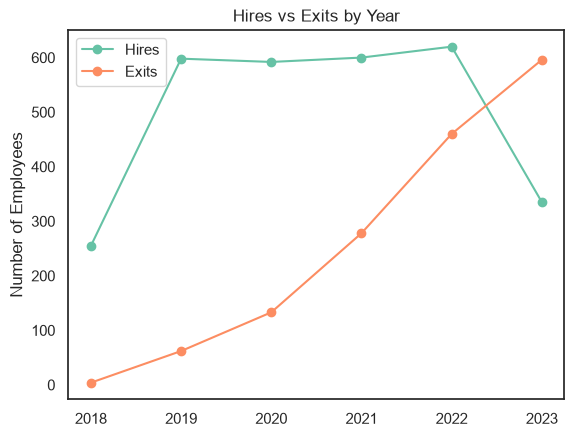

In [215]:
# Hires vs Exits per year line chart
hires = merged_emp_df['StartDate'].dt.year.value_counts().sort_index()
exits = merged_emp_df['ExitDate'].dt.year.value_counts().sort_index()
plt.plot(hires.index, hires, marker = 'o', label = 'Hires');
plt.plot(exits.index, exits, marker = 'o', label = 'Exits');
plt.title('Hires vs Exits by Year');
plt.ylabel('Number of Employees');
plt.legend();
plt.savefig('hires_vs_exits.png', transparent=True, dpi=300, bbox_inches='tight')

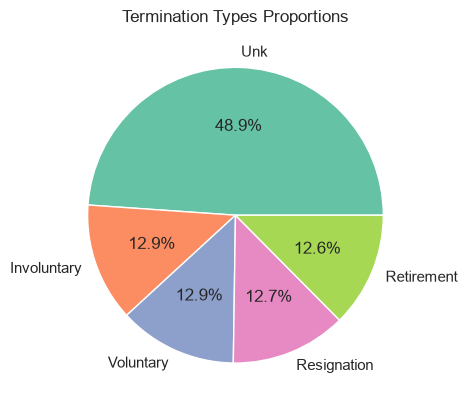

In [216]:
# Termination proportions pie chart
Gen_Termination = merged_emp_df['TerminationType'].value_counts(normalize=True)*100
Gen_Termination.plot(kind='pie', title = 'Termination Types Proportions', colors = pastel, autopct='%1.1f%%', ylabel='');
plt.savefig('Termination Types Proportions.png', transparent=True, dpi=300, bbox_inches='tight')

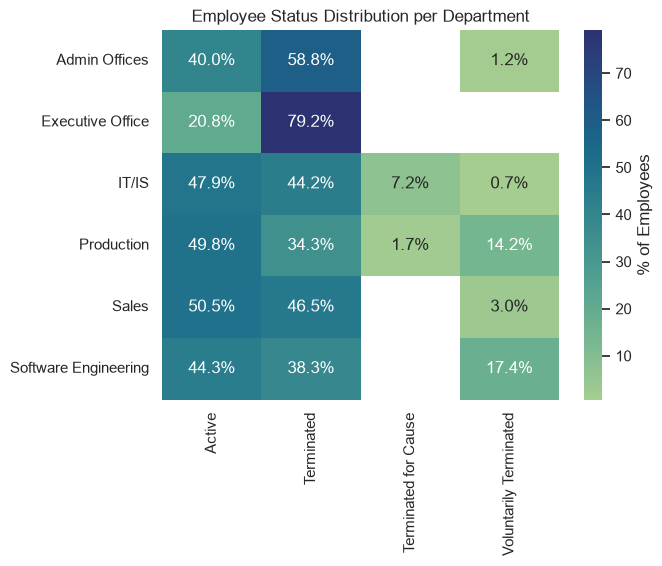

In [217]:
# Employee status per Department heatmap
Dep_Ter = merged_emp_df.groupby('DepartmentType')['EmployeeStatus'].value_counts(normalize=True).unstack()*100
sns.heatmap(Dep_Ter, annot=Dep_Ter.map(lambda x:f'{x:.1f}%'), fmt='', cmap= 'crest', cbar_kws={'label':'% of Employees'});
plt.title('Employee Status Distribution per Department');
plt.xlabel('');
plt.ylabel('');
plt.savefig('Employee Status Distribution per Department.png', transparent=True, dpi=300, bbox_inches='tight')

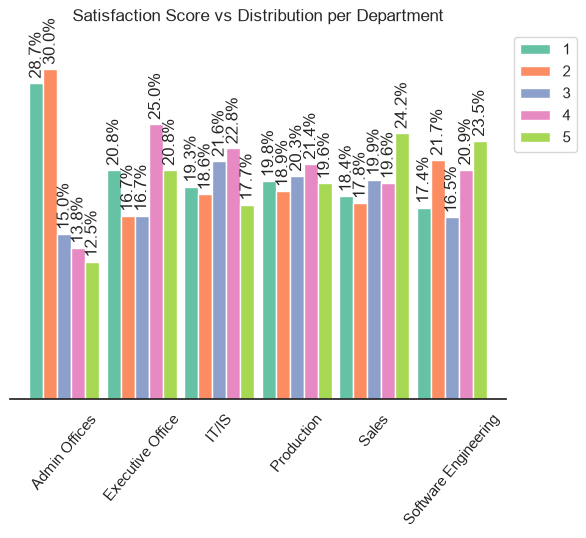

In [218]:
# employee satisfaction score per department clustered bar chart
dep_sat = merged_emp_df.groupby('DepartmentType')['Satisfaction Score'].value_counts(normalize=True).unstack()*100

chart = dep_sat.plot(kind = 'bar', stacked=False, rot=50, width = 0.90, title='Satisfaction Score vs Distribution per Department', xlabel = '');
plt.legend(bbox_to_anchor = (1,1),loc='upper left');
clean_chart(chart,labels=True,fmt='%.1f%%', rota = 90);
plt.savefig('Satisfaction Score vs Distribution per Department.png', transparent=True, dpi=300, bbox_inches='tight')

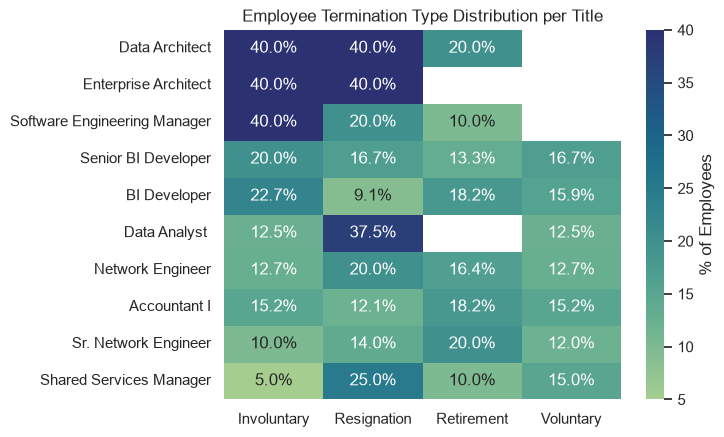

In [219]:
# employee termination type per job titles heatmap
Dep_Ter = merged_emp_df.groupby('Title')['TerminationType'].value_counts(normalize=True).unstack()*100
term_types = ['Involuntary','Resignation','Retirement','Voluntary']
top_titles = Dep_Ter[term_types].sum(axis=1).nlargest(10).index
dep_ter_top = Dep_Ter.loc[top_titles,term_types]
sns.heatmap(dep_ter_top, annot=dep_ter_top.map(lambda x:f'{x:.1f}%'), fmt='', cmap= 'crest', cbar_kws={'label':'% of Employees'});
plt.title('Employee Termination Type Distribution per Title');
plt.xlabel('');
plt.ylabel('');
plt.savefig('Employee Termination Type Distribution per Title.png', transparent=True, dpi=300, bbox_inches='tight')

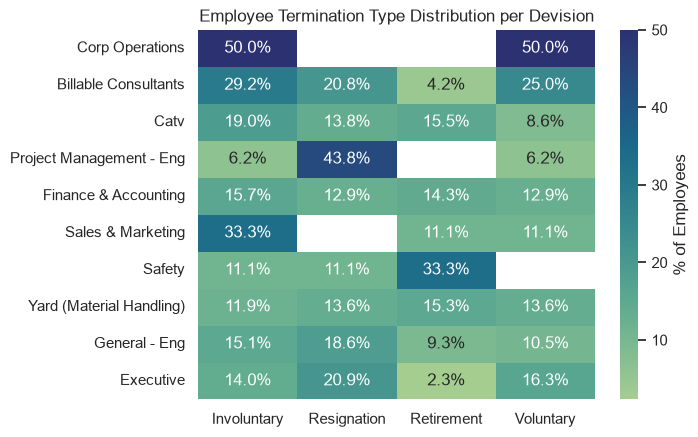

In [220]:
# employee termination type per division heatmap
Dev_Ter = merged_emp_df.groupby('Division')['TerminationType'].value_counts(normalize=True).unstack()*100
term_types = ['Involuntary','Resignation','Retirement','Voluntary']
top_devision = Dev_Ter[term_types].sum(axis=1).nlargest(10).index
Dev_Ter_top = Dev_Ter.loc[top_devision, term_types]
sns.heatmap(Dev_Ter_top, annot=Dev_Ter_top.map(lambda x:f'{x:.1f}%'), fmt='', cmap= 'crest', cbar_kws={'label':'% of Employees'});
plt.title('Employee Termination Type Distribution per Devision');
plt.xlabel('');
plt.ylabel('');
plt.savefig('Employee Termination Type Distribution per Devision.png', transparent=True, dpi=300, bbox_inches='tight')

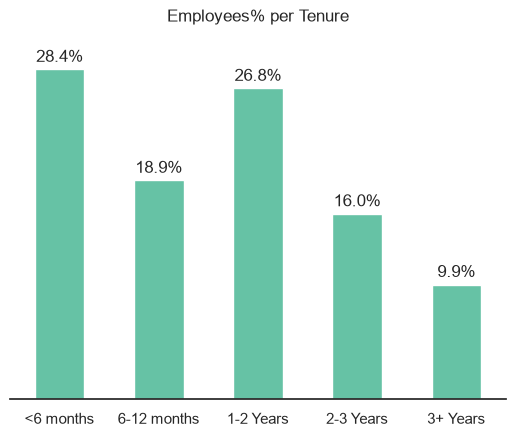

In [224]:
# Employees% termination period clustered bar chart
chart = merged_emp_df['TenureCat'].value_counts(normalize=True).mul(100).reindex(['<6 months','6-12 months', '1-2 Years','2-3 Years', '3+ Years']).plot(kind = 'bar', stacked=False, rot =0, title='Employees% per Tenure', xlabel = '');
clean_chart(chart,labels=True,fmt='%.1f%%', rota = 0);
plt.savefig('Employees% per Tenure.png', transparent=True, dpi=300, bbox_inches='tight')

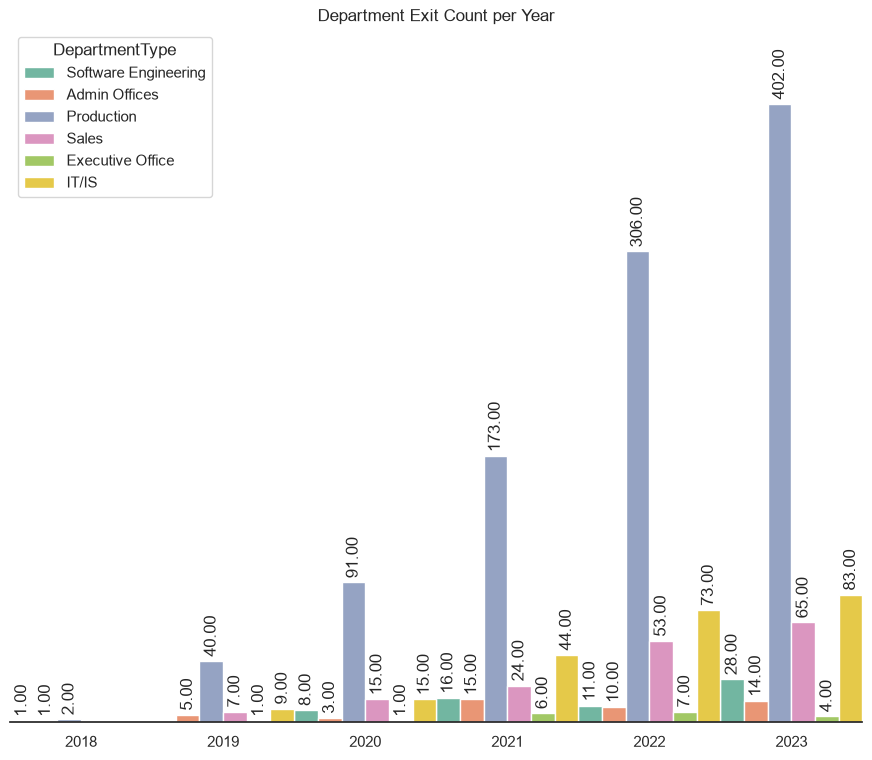

In [223]:
# Department Exit count per year
left=merged_emp_df[merged_emp_df['ExitDate'].notna()].copy()
left['ExitYear'] = left['ExitDate'].dt.year
plt.figure(figsize =(11,9))
chart = sns.countplot(data=left, x='ExitYear', width = 1, hue='DepartmentType', palette='Set2')
clean_chart(chart,labels=True,rota = 90);
plt.title('Department Exit Count per Year')
plt.xlabel('');
plt.savefig('Department Exit Count per Year.png', transparent=True, dpi=300, bbox_inches='tight')

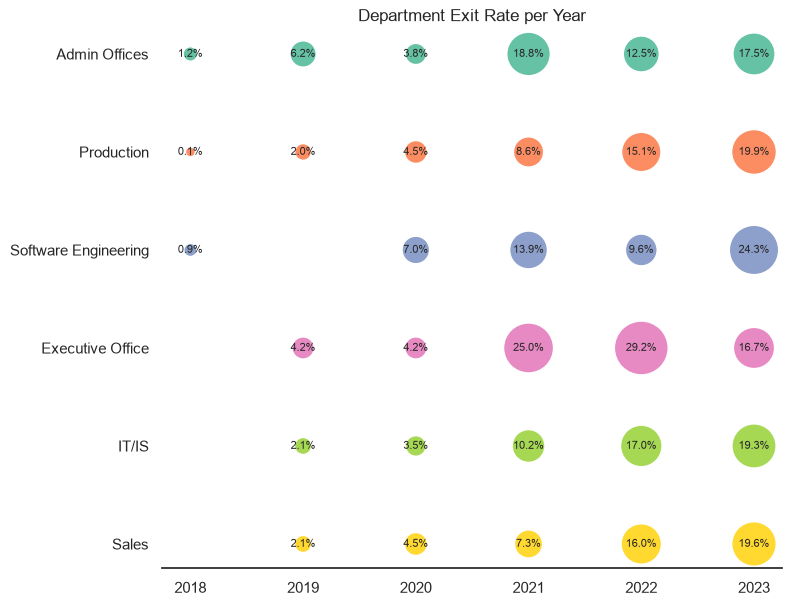

In [225]:
# Department Exit Rate per year bubble chart
headcount = merged_emp_df['DepartmentType'].value_counts()
left=merged_emp_df[merged_emp_df['ExitDate'].notna()].copy()
left['ExitYear'] = left['ExitDate'].dt.year
bubbles = left.groupby(['ExitYear', 'DepartmentType']).size().div(headcount,level='DepartmentType').mul(100).reset_index(name= 'ExitRate')
plt.figure(figsize =(8,7))
plt.title('Department Exit Rate per Year')
chart = sns.scatterplot(data=bubbles, x='ExitYear', y='DepartmentType',size='ExitRate',hue='DepartmentType', palette='Set2',sizes=(50,1500), legend=False)
chart.spines[['left','top','right']].set_visible(False)
for r,row in bubbles.iterrows():
    chart.text(row['ExitYear'], row['DepartmentType'],f'{row['ExitRate']:.1f}%', ha='center' , va='center', fontsize =8)
plt.xlabel('');
plt.ylabel('');
plt.savefig('Department Exit Rate per Year.png', transparent=True, dpi=300, bbox_inches='tight')

---

## Summary
__Summarizing the key insights from the analysis__

**Note**: _Use Bullet Points_

- The number of Exits has been always in a rising trend over the years, and has reached double the hires in 2023.
- Employees have leaving (Involutary, voluntary, Resignation, Retirement) for almost the same proportions.
- Admin offices and Excecutive office recorded the highest 'terminated' employees.
- The most termination describtion word was found to be 'fight'. Indicating problems inside the company.
- According to servays, Admin Offices employees rated law satisfaction rates compared to others.
- Also according to survays, Admin Offices and Executive office reported hight work-life balance rates compared to others, which might indicate little to no work at all in these departments.
- The most terminated jobs were (Data Architect,Enterprise Architect, Data Analyst and Software Engineering Managers) as the most Involutary and Resignation jobs
- Crop operations, sales and Marketing, and Billable consultants were the most terminated Divisions (Involutary), whereas project Managemnt-Eng reported as the most (Resignation) ones. Also Crop Operations were the highest to terminate voluntary.
- More than 50% of Employees terminate In less than 2 years from the company.
- The production department exit employees represent the most of exits.
- It seems like the exits started from the production department and then spreaded among the whole company.
- The company cannot explain why people leaves as the termination describtion appears to be meaningless.
    ...

## Recommendations/Conclusion
**Note**: _Use Bullet Points_
### Conclusion
- The company moved from study growth to a shrinking workforce in 2023, when exits passed hires for the first time. Leaving is not explained by the type of exit, performance, engagment scores or training, or even the description, all of these looked almost the same for people who stayed and people who left. The clearest pattern are the early exits about 1.1 year production for most of the 2023 loss and Admin and Executive Offices have the highest rates with the lowest satisfaction rates.

### Recommendations
- Write proper termination description to invitigate the exit reasons accuratly.
- Production employees contibutes with nearly half of the losses in 2023, which worth further analysis.
- Admin offices and Executive low satisfaction rates indicates managment or role problem leading to employees leaving the company.
- Moniter the IT roles (Data Architect, Enterprise Architect, Data Analyst) to lower the leaving rate.
- Do not hire the same number of people every year, the hiring process should be more flixible.

    ...